<h1><b>Statistique en Bioinformatique : </b> TME4 </h1>
<br>
L’objectif de ce TME sont:
<br>
<ul>
<li> objectif 1 : Utiliser les chaines de Markov pour comprendre les états phénotypiques de cellules cancéreuses.   </li>
<li> objectif 2 : étudier la dynamique des proportions phénotypiques dans les lignées cellulaires du cancer du sein humain: SUM159 et SUM149</li>
</ul>
<br>
<div class="alert alert-warning" role="alert" style="margin: 10px">
<p><b>Soumission</b></p>
<ul>
<li>Renomer le fichier TME3.ipynb pour NomEtudiant1_NomEtudiant2.ipynb </li>
<li>Soumettre sur moodle </li>
</div>


Nom etudiant 1 : Christine ANTON
<br>
Nom etudiant 2 : Elise NICOLAS
<br>

<h3>Introduction</h3>
<ul>
<li> Les cellules cancéreuses au sein des tumeurs existent souvent dans des états phénotypiques distincts.</li>
<li> Les sous-populations de cellules purifiées pour un état phénotypique reviennent vers des proportions d'équilibre dans le temps.</li>
<li> Cet équilibre peut s'expliquer par un modèle de Markov dans lequel les cellules passent de manière stochastique entre les états.  </li>
</ul>

<img src="img/CellStateTransition.png" />

<b>Exercice 1</b>:
Traduire les graphes de transition de la figure D en matrices de transition,
$P_{149}$ et $P_{159}$. Verifier bien que les matrices et les vecteur  $\pi_{0}$ soitent normalisés.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from matplotlib.legend_handler import HandlerLine2D
import random
import math as mt

#distribuition inicialle vecteur pi_0 S, L, B
pi0_149 = np.array([0.039, 0.033, 0.9280])
pi0_159 = np.array([0.019, 0.973, 0.0062])



#matrices
p_149 = np.array([[0.61, 0.30, 0.09], [0.01, 0.99, 0.00], [0.01, 0.08, 0.90]])


p_159 = np.array([[0.58, 0.07, 0.35], [0.04, 0.47, 0.49], [0.01, 0.00, 0.99]])

#Normaliser les vecteurs π0.




def normalise(m):
    """
    Normalise a matrix
    input1 m: matrix
    output1 mN: normalised matrix
    """
    row_sums = np.sum(m, axis=1)
    mN = m/row_sums[:, np.newaxis]
    
    return mN

print(normalise(p_149))
#[[0.61       0.3        0.09      ]
# [0.01       0.99       0.        ]
# [0.01010101 0.08080808 0.90909091]]


print (normalise(p_159))
#[[0.58 0.07 0.35]
# [0.04 0.47 0.49]
# [0.01 0.00 0.99]]

[[0.61       0.3        0.09      ]
 [0.01       0.99       0.        ]
 [0.01010101 0.08080808 0.90909091]]
[[0.58 0.07 0.35]
 [0.04 0.47 0.49]
 [0.01 0.   0.99]]


<b>Exercice 2</b>: Déterminer les états stationnaires
$\pi^\star_{149}$ et $\pi^\star_{159}$.
Est-ce que les valeurs que vous trouvez sont consistentes avec les
valeurs experimentales en Fig. 1?

In [2]:
#You can use the function numpy.linalg.eig
#https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

mat = np.array([[1, 2], [20, 60]])
eigenvalues, eigenvectors = np.linalg.eig(mat)

print(eigenvalues, "\n", eigenvectors)

def stationary_distribution_fixed_point_VP(A, epsilon=1e-6):
    val_propres, vect_propres = np.linalg.eig(A.transpose())
    vect_propre_1 = vect_propres[:, np.where(np.isclose(val_propres, 1.0, atol=epsilon))[0][0]]

    return vect_propre_1 / vect_propre_1.sum()


pi_stat_149 = stationary_distribution_fixed_point_VP(normalise(p_149))
pi_stat_159 = stationary_distribution_fixed_point_VP(normalise(p_159))


print("Pi star 149 ", pi_stat_149)
print("Pi star 159 ", pi_stat_159)

#Pi star 149  [0.02500625 0.95023756 0.02475619]
#Pi star 159  [0.0234721  0.00310009 0.97342781]

[ 0.32965032 60.67034968] 
 [[-0.94815818 -0.03349867]
 [ 0.31779877 -0.99943876]]
Pi star 149  [0.02500625 0.95023756 0.02475619]
Pi star 159  [0.0234721  0.00310009 0.97342781]


<b>Exercice 3</b>: Déterminer les matrices de transition $P_{149}^n$ et $P_{159}^n$ pour $n$
iterations avec $n=2,4,8,16,32,64$, imprimer toutes les matrices. Computer les vectors $\pi^{(n)}$ et les comparer avec
$\pi^\star_{149,159}$. Utilisez le $\pi^0$ du papier de Gupta, page 2, ci-dessous.

In [3]:
pi_zero_149 = np.array([[0.039, 0.928, 0.033]])
pi_zero_159 = np.array([[0.019, 0.0062, 0.973]])


#matrice P**n
def matTransN(P, n):
    """
    Compute the transition matrix after N iterations
    input1 P: matrix
    input2 n: number of iterations
    output Pn: transition matrix after N iterations
    """
    Pn = np.linalg.matrix_power(P, n)
    
    return Pn

#matrice P**n where n = 2,4,8,16,32,64
def printMatPi(P, n, pi_0, M_name):
    """
    Print all P**n matrices and pi_n, where n in {2,4,8,16,32,64, ...}
    input1 P: matrix
    input2 n: number of iterations
    input3 pi_0: initial condition
    input4 M_name: matrix identifier
    output: None
    """
    P_n = matTransN(P, n)
    print(P_n)
    pi_n = pi_0 @ P_n
    print((pi_n))


printMatPi(p_149, 64, pi_zero_149, '149')
printMatPi(p_159, 64, pi_zero_159, '159')

[[0.02416851 0.91989042 0.0221253 ]
 [0.02472519 0.94145904 0.02226683]
 [0.0222511  0.84601362 0.02123839]]
[[0.02462184 0.93746816 0.02222737]]
[[0.0234721  0.00310009 0.97342781]
 [0.0234721  0.00310009 0.97342781]
 [0.0234721  0.00310009 0.97342781]]
[[0.02342985 0.00309451 0.97167564]]


<b> Exercice 4 </b>:
 Ecrire une fonction pour déterminer les
$(\pi^{(t)})_{t=1:n}$ d'une chaine de Markov à trois états. Appliquer
pour $P_{149}$ et $P_{159}$, pour les conditions initiales
$\pi^{(0)}\in\{ (0.998,0.001,0.001), (0.001,0.998,0.001),
(0.001,0.001,0.998) \}$ et pour $n=20$ itérations de la chaine
de Markov. Visualiser graphiquement les résultats.


In [4]:

def Pi_n(pi_0, P, n):
    """
    Compute Pi_n = Pi_0*P^n
    input1 pi_0: intial condition
    input2 P: transition matrix
    input3 n: number of iterations
    output Pi_n
    """
    P_n = matTransN(P, n)
    Pi_n = pi_0 @ P_n

    return Pi_n


In [5]:
def List_Pi_n(pi0, P, n):
    """
    Compute a list of  Pi_n
    input1 pi_0: intial condition
    input2 P: transition matrix
    input3 n: number of iterations
    output liste_M_trans: list
    """
    liste_Pi_n=[pi0]

    for i in range(1, n+1):
        liste_Pi_n.append(Pi_n(pi0, P, i))

    return np.array(liste_Pi_n)


In [6]:
def plot(liste_Pi_n):
    """
    Plot liste_Pi_n
    """
    x_axis = np.linspace(0,20,21)
    plt.figure()
    for i in range(liste_Pi_n.shape[1]) :
        plt.plot(x_axis, liste_Pi_n[:, i], label=f"state {i}")

    plt.xlabel("Number of iterations (n)")
    plt.ylabel("State probabilities at time n")
    plt.title("Evolution of state probabilities depending on number of iterations n")
    plt.legend()
    plt.show()


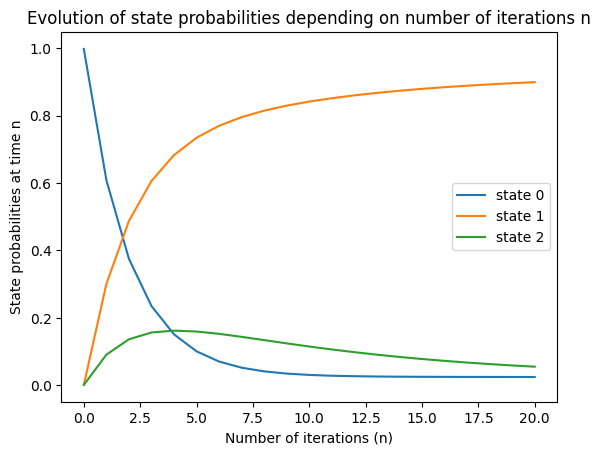

In [7]:
pi1 = np.array([0.998,0.001,0.001])
plot(List_Pi_n(pi1, p_149, 20))

<b> Exercice 5 </b>:
Ecrire une fonction pour simuler la trajectoire stochastique
$(x_t)_{t=0:n}$ d'une seule réalisation de la chaiine de Markov.
Créer des population de $N=10,100,1000,10000$ trajectoires. Estimer
la trajectoire moyenne de chaque population.


In [38]:
def Trajectoire (n, Pi_0, P):
    """
    simulate the stochastic trajectory
    input1 n: number of iterations
    input2 Pi_0: initial condition
    input3 P: transtion matrix
    output Traj: list of states that simulates the stochastic trajectory ['S', 'B', 'L']
    """
    Traj = []
    proba = Pi_0

    for i in range(n):
        nb= random.random()
        if nb < proba[0] :
            Traj.append('S')
            proba=P[0]
        elif nb <(proba[0]+proba[1]):
            Traj.append('B')
            proba = P[1]
        else : 
            Traj.append('L')
            proba=P[2]
    return Traj

#Déterminer une trajectoire pour N population.
def Trajectoire_P(n, Pi_0, P, N):
    """
    Simulate a trajectory for N population.
    input1 n: number of iterations
    input2 Pi_0: initial condition
    input3 P: transtion matrix
    input3 N: population size
    output TrajP: trajectory
    """
    TrajP=[]
    for i in range(N) :
        TrajP.append(Trajectoire(n, Pi_0, P))
    return TrajP


#Estimer la trajectoire moyenne d'une chaine de markov pou N

def Trajectoire_moy(n, Pi_0, P, N):
    """
    Find the mean tragetoire
    input1 n: number of iterations
    input2 Pi_0: initial condition
    input3 P: transtion matrix
    input3 N: population size
    output TrajMoy: mean trajectory
    """

    TrajMoy = np.zeros((3,n))

    TrajP = Trajectoire_P(n, Pi_0, P, N)
    
    for pos in range(n):
        for seq in range(N) :
            for i, res in enumerate (["S", "B", "L"]) :
                if TrajP[seq][pos]==res :
                    TrajMoy[i,pos] +=1
    
    TrajMoy = TrajMoy/n

    return TrajMoy

#Visualiser graphique des trajectoires.
def plotTrajectory(t):
    """
    Plot Trajectory
    input1 t: trajectory
    """
    r, n = t.shape
    x = np.arange(0,n)
    res = ["S", "B", "L"]
    plt.figure()
    for i in range(r) :
        plt.plot(x, t[i], label=f"state {res[i]}")
    plt.legend()
    plt.xlabel("Position in the Markov Chain (n)")
    plt.ylabel("Probability")
    plt.show()



[[0.45 0.35 0.15 0.15 0.15 0.05 0.   0.   0.   0.   0.05 0.05 0.05 0.05
  0.05 0.05 0.05 0.   0.   0.  ]
 [0.   0.1  0.2  0.2  0.2  0.3  0.3  0.3  0.35 0.35 0.3  0.35 0.35 0.35
  0.35 0.35 0.35 0.45 0.45 0.45]
 [0.05 0.05 0.15 0.15 0.15 0.15 0.2  0.2  0.15 0.15 0.15 0.1  0.1  0.1
  0.1  0.1  0.1  0.05 0.05 0.05]]


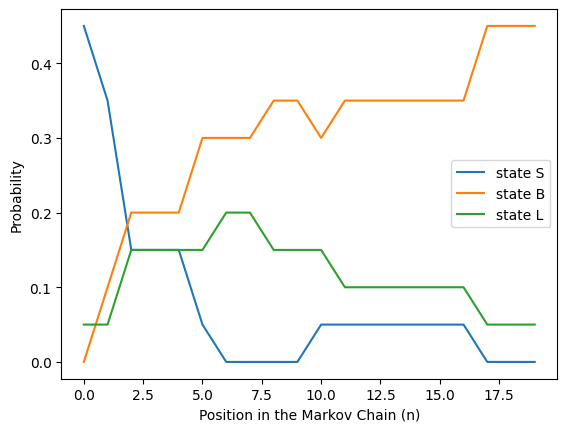

In [39]:
t = Trajectoire_moy(20, pi1, p_149, 10)
print(t)
plotTrajectory(t)

<b> Exercice 6 </b>:
Ecrire une fonction pour calculer la probabilité d'une trajectoire
$(x_t)_{t=0:n}$. Pour y facilite vous devez applique le log et utlise la some au
lieu du product.  Ensuite vouz devez comparer les probabilités de
deux chaiines de Markov $P_{149}$ et $P_{159}$. Visualiser les histogrammes pour les deux populations de taille $N=10000$ (géenérées avec $P_{149}$ et $P_{159}$). Est-ce que vous observez des différences entre les deux modèles? Comment est-ce que vous expliquer cettes différences?

In [ ]:
#Calculer la probabilité d’une trajectoire (xt)t=0:n
def Pb_Trajectoire(Traj, Pi_0, P):
    """
    Compute the probability of a trajectory
    input1 Traj: a trajectory
    input2 Pi_0: initial condition
    input3 P: transtion matrix
    output Proba: ptobability
    """
    n = len(Traj)
    Proba = Pi_0
    for pos in range(0,n, -1) :
        
    return Proba


def Histo (Trajs, Pi_0, P):
    """
    compute a histogramm of Trajectory probabilities
    input1 Trajs: a trajectory population
    input2 Pi_0: initial condition
    input3 P: transtion matrix
    output pop: a list of probabilities
    """

    pop = []

    return pop

def plotHist(Histo149, Histo159):
    """
    Plot two probabilities histogram
    input1 Histo149: a list of probabilities for P149
    input1 Histo159: a list of probabilities for P159
    """


#-------------------------------------------------------------
plotHist(Histo(Trajectoire_P(20, pi0_149, p_149, 10000),pi0_149, p_149), Histo(Trajectoire_P(20, pi0_159, p_159, 10000),pi0_159, p_159))
